# Transcript Cleaning Pipeline 
## Isolated into one notebook
### Built based upon McCray Metadata


In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import re, ast, json, csv
from utils.constants import Paths
from utils.ocr_cleaning import OCR_Clean, OCR_Check
import nltk
from nltk.corpus import words, PlaintextCorpusReader

### Get original metadata

In [2]:
# Get original metadata
dataset = "simkins"
dataset_cap = "Simkins"
df = pd.read_csv(rf"../data/{dataset}/original_data/{dataset_cap} metadata.csv")
print(list(df))

def save_csv(df, title):
    df.to_csv(title,
          index=False,
          encoding='utf-8',
          quoting=csv.QUOTE_NONNUMERIC,   
          escapechar='\\',
          lineterminator='\n')

# # # nltk download
# # nltk.download('words')
# english_vocab = set(w.lower() for w in words.words())

wordlists = PlaintextCorpusReader('../data/mccray', 'combined_words_corpus.txt')

print(len(df))

['Title', 'Creator', 'Contributors', 'Date', 'Extent', 'Source', 'Keywords', 'Description', 'Digital Collection', 'Website', 'Contributing Institution', 'SC County', 'Rights', 'Language', 'Digitization Specifications', 'Date Digital', 'Type', 'Format', 'Media Type', 'Identifier', 'Digital Assistant', 'Transcription', 'Series', 'OCLC number', 'Date created', 'Date modified', 'Reference URL', 'CONTENTdm number', 'CONTENTdm file name', 'CONTENTdm file path']
12684


### Handle the fields / basic standardization

In [3]:
# Add 'Year' field
df['Year'] = df['Date']
df['Year'] = df['Year'].apply(lambda x: str(x))
df['Year'] = df['Year'].apply(lambda x: re.sub(r'[^0-9]+', "", x))
df['Year'] = df['Year'].apply(lambda x: x[:4])

# Handle Transcript Column Name Differences
if('Transcript' not in df.columns):
    df['Original Transcript'] = df['Transcription'] 
    df = df.drop('Transcription', axis=1)  
else:
    df['Original Transcript'] = df['Transcript'] 
    df = df.drop('Transcript', axis=1)  

# Replace empty transcripts with na
df['Original Transcript'] = df['Original Transcript'].fillna('').apply(lambda x: x.strip() if isinstance(x, str) else '')

# Add "Original Len" Column for lengths
df['Original Len'] = df['Original Transcript'].str.replace(r'\s+', '', regex=True).str.len()

### Determining messiness and provide details on transcripts

In [4]:
# Helper to find sequences using regex pattern, allowing for exceptions (created for some patterers in OCR_Clean class)
def find_sequences(pattern, text, exceptions=[]):
    candidates = re.findall(pattern, str(text))
    flagged = []
    for candidate in candidates:
        if not any(re.match(exc, candidate) for exc in exceptions):
            flagged.append(candidate)
    return flagged

# Updated data cleaning metrics with new structure
transcript_col = 'Original Transcript'

# Individual pattern detection (Boolean columns)
df['Special Pattern'] = df[transcript_col].apply(lambda x: len(find_sequences(OCR_Clean.special_pattern, x)) > 0)
df['General Pattern'] = df[transcript_col].apply(lambda x: len(find_sequences(OCR_Clean.general_pattern, x, OCR_Clean.general_exceptions)) > 0)
df['Repeat Chars'] = df[transcript_col].apply(lambda x: len(find_sequences(OCR_Clean.letter_pattern, x)) > 0)
df['Short/No Transcript'] = df['Original Len'] < 20

# Overall messiness/quaility indicator
df['Quality'] = ~(df['Special Pattern'] | df['General Pattern'] | df['Repeat Chars'] | df['Short/No Transcript'])

# Issue Types (List of Strings)
def get_issue_types(row):
    types = []
    if row['Special Pattern']:
        types.append('Special Char Artifacts')
    if row['General Pattern']:
        types.append('General Artifacts')
    if row['Repeat Chars']:
        types.append('Repeat Chars')
    if row['Original Len'] == 0:
        types.append('Empty Transcript')
    elif row['Short/No Transcript']:
        types.append('Low Char Count')
    return types

df['Issue Types'] = df.apply(get_issue_types, axis=1)

# Detected Artifacts (List of Strings)
def get_detected_artifacts(text):
    artifacts = []
    # Add special pattern artifacts
    artifacts.extend(find_sequences(OCR_Clean.special_pattern, text))
    # Add general pattern artifacts
    artifacts.extend(find_sequences(OCR_Clean.general_pattern, text, OCR_Clean.general_exceptions))
    # Add repeat character sequences
    artifacts.extend(find_sequences(OCR_Clean.letter_pattern, text))
    return artifacts

df['Detected Artifacts'] = df[transcript_col].apply(get_detected_artifacts)

# Data Isolations
## get empty and repeat transcripts

In [5]:
print(list(df), "\n")

# Remove [].cpd documents (previously captured by empty docs, but this covers clear seperation / reason behind empty transcripts)
df_cpd = df[df['CONTENTdm file name'].str.split('.').str[1] == 'cpd']
df_jp2 = df[df['CONTENTdm file name'].str.split('.').str[1] != 'cpd']

# Remove empty documents (where Original Transcript is empty or NaN)
df_pure_empty = df_jp2[df_jp2['Original Transcript'].isna() | (df_jp2['Original Transcript'].str.strip() == '')]
df_no_empty = df_jp2[df_jp2['Original Transcript'].notna() & (df_jp2['Original Transcript'].str.strip() != '')]

# Remove repeated documents (same Original Transcript content, different IDs)
# Keep first occurrence of each unique transcript
df_repeated = df_no_empty[df_no_empty.duplicated(subset=['Original Transcript'], keep=False)]
df_no_repeat = df_no_empty.drop_duplicates(subset=['Original Transcript'], keep='first')


['Title', 'Creator', 'Contributors', 'Date', 'Extent', 'Source', 'Keywords', 'Description', 'Digital Collection', 'Website', 'Contributing Institution', 'SC County', 'Rights', 'Language', 'Digitization Specifications', 'Date Digital', 'Type', 'Format', 'Media Type', 'Identifier', 'Digital Assistant', 'Series', 'OCLC number', 'Date created', 'Date modified', 'Reference URL', 'CONTENTdm number', 'CONTENTdm file name', 'CONTENTdm file path', 'Year', 'Original Transcript', 'Original Len', 'Special Pattern', 'General Pattern', 'Repeat Chars', 'Short/No Transcript', 'Quality', 'Issue Types', 'Detected Artifacts'] 



In [6]:
# print counts of inital isolations
print(f'cpd count: {len(df_cpd)} / {len(df)} -- {len(df_cpd)} docs are "cpd" / collections')
print(f'Empty count: {len(df_pure_empty)} / {len(df)} -- {len(df_pure_empty)} docs need rescanned due null content')
print(f'Repeated count: {len(df_repeated)} / {len(df_no_empty)} -- {len(df_repeated)} docs need are not needed due to being repeated content') 

# save empty and repeated
save_csv(df_cpd, f"../data/{dataset}/split_data/h1_split/D_{dataset[0:3]}_cpd.csv")
save_csv(df_pure_empty, f"../data/{dataset}/split_data/h1_split/D_{dataset[0:3]}_0.csv")
save_csv(df_repeated, f"../data/{dataset}/split_data/h1_split/D_{dataset[0:3]}_rep.csv")

df = df_no_repeat.copy()

cpd count: 167 / 12684 -- 167 docs are "cpd" / collections
Empty count: 1273 / 12684 -- 1273 docs need rescanned due null content
Repeated count: 12 / 11244 -- 12 docs need are not needed due to being repeated content


In [7]:
# Save all OG Transcripts w/ Quality=True to 'Semi-clean Transcripts'
sc_v1_col = f'D_{dataset[0:3]}_cleaned_v1'
sc_v2_col = f'D_{dataset[0:3]}_cleaned_v2'

### Pre proccessing to turn OG transcripts w/ issues into semi-clean transcripts
#### V1 cleaning first

In [8]:
# Save all OG Transcripts w/ Quality=True to 'Semi-clean Transcripts'
df[sc_v1_col] = df['Original Transcript'].where(df['Quality'] == True, "") 

df['Cleaning'] = df['Original Transcript'].where(
	(df['Quality'] == False) & (df['Short/No Transcript'] == False), ""
).astype(str)

# Pattern removal and condence patterns for semi-cleaning
df['Cleaning'] = df['Cleaning'].apply(lambda x: re.sub(OCR_Clean.letter_pattern, '\\1', x))
df['Cleaning'] = df['Cleaning'].apply(lambda x: re.sub(OCR_Clean.special_pattern, "", x))
df['Cleaning'] = df['Cleaning'].apply(lambda x: re.sub(OCR_Clean.general_pattern, "", x))

# Combine the columns which were the most clean, and placed in semi-clean, with the newly 'Cleaning' column
df[sc_v1_col] = df.apply(
    lambda r: r['Original Transcript']
        if (pd.notna(r['Original Transcript']) and r.get('Quality', False))
        else (r['Cleaning'] if str(r.get('Cleaning','')).strip() != '' else r['Original Transcript']),
    axis=1
).astype(str)

df = df.drop('Cleaning', axis=1)

# Regex pattern for this:
# To remove ^ and ^+shortphrases, and remove standalone punctuation not attached to words/numbers.

# \^(\w{0,4})   matches ^ followed by 0–4 word characters (short phrases like ^a, ^ok, ^xyz, ,^fele or just ^)
# |             OR
# (?<!\w)       negative lookbehind: ensures the char before is NOT a word character
# [^\w\s]      matches any single character that is NOT a word char and NOT whitespace and not $ % &
# (?!\w)        negative lookahead: ensures the char after is NOT a word character

p1 = r"\^(\w{0,4})|(?<!\w)[^\w\s](?!\w)"

df[sc_v1_col] = df[sc_v1_col].apply(lambda x: re.sub(p1, "", x))

# Clean spacing (with auto newlining)
def normalize_spaces(text):
	return re.sub(r" {2,}", lambda m: "\n" if len(m.group(0)) > 3 else " ", text)

df[sc_v1_col] = df[sc_v1_col].apply(normalize_spaces)

df['sc_v1_len'] = df[sc_v1_col].str.replace(r'\s+', '', regex=True).str.len()


### V2 cleaning, more simple: html sub, pattern removal, and ocr_patterns sub                                                                                                              

In [9]:
# HTML Entity Decoding Function
import html.entities

_entity_re = re.compile(r'&(#?)(x?)(\w+);', re.IGNORECASE)

def html_decode(s: str) -> str:
    def _repl(m):
        is_num = m.group(1) == '#'
        is_hex = m.group(2).lower() == 'x'
        body = m.group(3)

        try:
            if is_num:
                codepoint = int(body, 16 if is_hex else 10)
                return chr(codepoint)
            else:
                # named entity
                cp = html.entities.name2codepoint.get(body)
                if cp is not None:
                    return chr(cp)
        except Exception:
            pass
        # unknown — return original text unchanged
        return m.group(0)

    return _entity_re.sub(_repl, s)

print(html_decode("&gt;&gt;&gt;!$"))         # >>>!$
print(html_decode("Price: &dollar;100"))   # Price: &dollar;100  (&#36; or &amp;#36; would decode)
print(html_decode("A = &#65;, B = &#x42;"))# A = A, B = B

>>>!$
Price: &dollar;100
A = A, B = B


In [10]:
df[sc_v2_col] = df['Original Transcript'].copy()

# html decode
df[sc_v2_col] = df[sc_v2_col].apply(html_decode)

# Only clean special pattern
df[sc_v2_col] = df[sc_v2_col].apply(lambda x: re.sub(OCR_Clean.non_ascii_between_ascii, " ", x))
df[sc_v2_col] = df[sc_v2_col].apply(lambda x: re.sub(OCR_Clean.non_ascii, "", x))
# df[sc_v2_col] = df[sc_v2_col].apply(lambda x: re.sub(OCR_Clean.letter_pattern_4, '\\1', x))

# test
st = "securedΓÇönumber testΓÇötext ñ ñ ΓÇöΓÇöΓÇöΓÇöΓÇöΓÇö"
print("test string:", st)
st = re.sub(OCR_Clean.non_ascii_between_ascii, " ", st)
print("non_ascii_between_ascii:", st)
st = re.sub(OCR_Clean.non_ascii, "", st)
print("non_ascii:", st)

# # Alternative: use OCR_Clean class method to clean text
# compiled_patterns = OCR_Clean.compile()
# df[sc_v2_col] = df[sc_v2_col].apply(lambda x: OCR_Clean.clean_ocr_text(x, compiled_patterns))

# apply ocr_patterns dictionary substitutions
compiled_patterns = OCR_Clean.compile()

changes_log = []

# Track and apply changes
for pattern, replacement in OCR_Clean.ocr_patterns.items():
    mask = df[sc_v2_col].str.contains(pattern, regex=True, na=False)
    
    if mask.any():
        # Log the changes
        for idx in df[mask].index:
            changes_log.append({
                'before': df.loc[idx, sc_v2_col],
                'pattern': pattern,
                'replacement': replacement,
                "after": re.sub(pattern, replacement, df.loc[idx, sc_v2_col])
            })
        
        # Apply the change
        df[sc_v2_col] = df[sc_v2_col].str.replace(pattern, replacement, regex=True)

# Create changes dataframe
changes_df = pd.DataFrame(changes_log)

# Save changes log to a CSV file
changes_df.to_csv(f"{dataset}_replacement_log.csv", index=False)

# Clean spacing (with auto newlining)
def normalize_spaces(text):
    return re.sub(r" {2,}", lambda m: "\n" if len(m.group(0)) > 3 else " ", text)

df[sc_v2_col] = df[sc_v2_col].apply(normalize_spaces)

df['sc_v2_len'] = df[sc_v2_col].str.replace(r'\s+', '', regex=True).str.len()


test string: securedΓÇönumber testΓÇötext ñ ñ ΓÇöΓÇöΓÇöΓÇöΓÇöΓÇö
non_ascii_between_ascii: secured number test text ñ ñ Γ ö
non_ascii: secured number test text    


In [11]:
# keep = ['CONTENTdm number', 'Reference URL','Title',
#  'Description',
#  'Date',
#  'Year',
#  'Original Transcript',
#  f'D_{dataset[0:3]}_cleaned_v1',
#  f'D_{dataset[0:3]}_cleaned_v2',
#  'Original Len',
#  'sc_v1_len',
#  'sc_v2_len',
#  'Issue Types',
#  'Detected Artifacts',
#  'CONTENTdm file name',
#  'Source',
#  'Subject',
#  'Local Subject',
#  'S.C. County',
#  'Digital Collection',
#  'Contributing Institution',
#  'Rights',
#  'Time Period',
#  'Geographic Location',
#  'Note'
# ]

# for col in df.columns:
#     if col not in keep:
#         df = df.drop(col, axis=1)
        
display(df[df["Title"] == 'Card, 1959 December 22, A Christmas Card from the Northrop Family, page 3'])
print(df[df["Title"] == 'Card, 1959 December 22, A Christmas Card from the Northrop Family, page 3'])
save_csv(df, f"../data/{dataset}/split_data/h1_split/D_{dataset[0:3]}_h1_main.csv")

df


,Title,Creator,Contributors,Date,Extent,Source,Keywords,Description,Digital Collection,Website,...,General Pattern,Repeat Chars,Short/No Transcript,Quality,Issue Types,Detected Artifacts,D_sim_cleaned_v1,sc_v1_len,D_sim_cleaned_v2,sc_v2_len


Empty DataFrame
Columns: [Title, Creator, Contributors, Date, Extent, Source, Keywords, Description, Digital Collection, Website, Contributing Institution, SC County, Rights, Language, Digitization Specifications, Date Digital, Type, Format, Media Type, Identifier, Digital Assistant, Series, OCLC number, Date created, Date modified, Reference URL, CONTENTdm number, CONTENTdm file name, CONTENTdm file path, Year, Original Transcript, Original Len, Special Pattern, General Pattern, Repeat Chars, Short/No Transcript, Quality, Issue Types, Detected Artifacts, D_sim_cleaned_v1, sc_v1_len, D_sim_cleaned_v2, sc_v2_len]
Index: []

[0 rows x 43 columns]


,Title,Creator,Contributors,Date,Extent,Source,Keywords,Description,Digital Collection,Website,...,General Pattern,Repeat Chars,Short/No Transcript,Quality,Issue Types,Detected Artifacts,D_sim_cleaned_v1,sc_v1_len,D_sim_cleaned_v2,sc_v2_len
0,Letter from Venice T. Springs of the National ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,[Special Char Artifacts],"[â€œ, â€]","For Alabama 341 Martin Building, Birmingham Ja...",1441,"For Alabama 341 Martin Building, Birmingham Ja...",1441
1,Letter from Venice T. Springs of the National ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,[Special Char Artifacts],"[â€œ, â€]",Period. Our latch string is always on the out-...,299,Period. Our latch string is always on the out-...,299
2,"Letter to Mary E. Williams, Director of Studen...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,[Special Char Artifacts],"[â€œ, â€]","March 6, 1941. Miss Mary E. Williams, B.M. Dir...",1661,"March 6, 1941. Miss Mary E. Williams, B.M. Dir...",1662
3,"Letter to Mary E. Williams, Director of Studen...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,[Special Char Artifacts],"[â€œ, â€]",very likely to the fact that they (illegible) ...,2317,very likely to the fact that they (illegible) ...,2317
6,"Last Will and Testamnet of Ernest Garnes, date...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,True,False,False,[Repeat Chars],[I],STATS OF SOUTH CAROLINA COUNTY OF RICHLAND LAS...,1259,STATS OF SOUTH CAROLINA COUNTY OF RICHLAND LAS...,1262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11510,"Passport Issued July 21, 1961, Page 5",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,True,True,False,False,"[Special Char Artifacts, General Artifacts, Re...","[â€”, â€”, â€”, â€”, â€”, â–, Â»Â», Â», __^_^_...",INTERNATIONAL CERTIFICATES OF VACCINATION AS A...,442,INTERNATIONAL CERTIFICATES OF VACCINATION AS A...,478
11511,"Passport Issued July 21, 1961, Page 6",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,True,False,False,False,"[Special Char Artifacts, General Artifacts]","[Â£, Â®, Â«â€¢*&, â€¢, **â–, **, Â», Â», Â°, Â...",H9 INTERNATIONAL CERTIFICATE OF VACCINATION OR...,1056,H9 INTERNATIONAL CERTIFICATE OF VACCINATION OR...,1107
11512,"Passport Issued September 22, 1949, Page 1",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,True,False,False,False,"[Special Char Artifacts, General Artifacts]","[\\, a~4&gt]",IMPORTANT The person to whom this passport is ...,457,IMPORTANT The person to whom this passport is ...,474
11513,"Passport Issued September 22, 1949, Page 2",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,True,[],[],"SEE PAGES 6, 7. AND 8 FOR MNEWAL. EXTENSIONS, ...",76,"SEE PAGES 6, 7. AND 8 FOR MNEWAL. EXTENSIONS, ...",76


In [12]:
problem = df[
    (df[f'D_{dataset[0:3]}_cleaned_v1'].astype(str).str.strip() == "") &
    (df[f'D_{dataset[0:3]}_cleaned_v2'].astype(str).str.strip() != "")
]
print("v1 empty but v2 non-empty:", len(problem))
display(problem[['CONTENTdm file name','Original Transcript',f'D_{dataset[0:3]}_cleaned_v1',f'D_{dataset[0:3]}_cleaned_v2','Original Len']])

v1 empty but v2 non-empty: 4


,CONTENTdm file name,Original Transcript,D_sim_cleaned_v1,D_sim_cleaned_v2,Original Len
904,1410.jp2,/,,/,1
2406,3118.jp2,*,,*,1
4711,5423.jp2,.,,.,1
7752,9139.jp2,) .,,) .,2


## Metrics

In [13]:
# Metrics
# skip -- just do in metrics notebook 
# - --- IGNORE ---

## Data viz

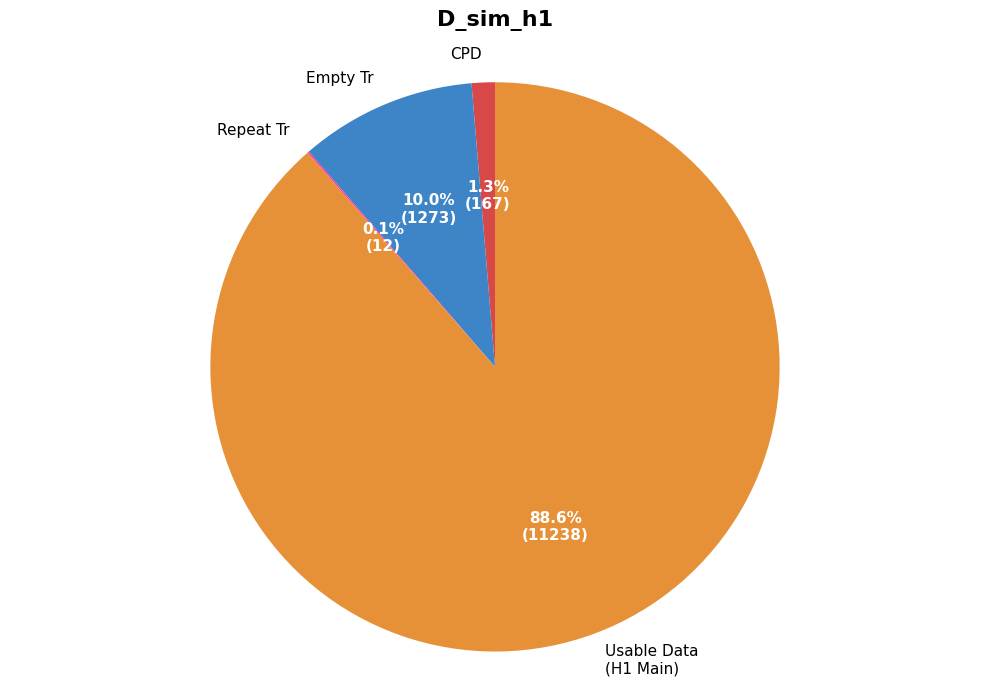

In [14]:
import matplotlib.pyplot as plt

# data
categories = ['CPD', 'Empty Tr', 'Repeat Tr', 'Usable Data\n(H1 Main)']
values = [len(df_cpd), len(df_pure_empty), len(df_repeated), len(df)]

# Create pie chart
fig, ax = plt.subplots(figsize=(10, 7))

# Create the pie chart with customizations
wedges, texts, autotexts = ax.pie(
    values,
    labels=categories,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100.*sum(values))})',  # Show percentages and counts
    startangle=90,       # Start from top
    colors=['#d94848', '#3d85c6', "#ff36a5", '#e69138'],
    textprops={'fontsize': 11}
)

# Enhance the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Add title
plt.title(f'D_{dataset[0:3]}_h1', fontsize=16, fontweight='bold', pad=20)

# Equal aspect ratio ensures circular pie
ax.axis('equal')

plt.tight_layout()


In [15]:
list(df)


['Title',
 'Creator',
 'Contributors',
 'Date',
 'Extent',
 'Source',
 'Keywords',
 'Description',
 'Digital Collection',
 'Website',
 'Contributing Institution',
 'SC County',
 'Rights',
 'Language',
 'Digitization Specifications',
 'Date Digital',
 'Type',
 'Format',
 'Media Type',
 'Identifier',
 'Digital Assistant',
 'Series',
 'OCLC number',
 'Date created',
 'Date modified',
 'Reference URL',
 'CONTENTdm number',
 'CONTENTdm file name',
 'CONTENTdm file path',
 'Year',
 'Original Transcript',
 'Original Len',
 'Special Pattern',
 'General Pattern',
 'Repeat Chars',
 'Short/No Transcript',
 'Quality',
 'Issue Types',
 'Detected Artifacts',
 'D_sim_cleaned_v1',
 'sc_v1_len',
 'D_sim_cleaned_v2',
 'sc_v2_len']